In [1]:
import cv2
import mediapipe as mp
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import urllib.request
import math
from pathlib import Path

In [2]:

# CONFIGURAÇÃO — caminhos de entrada/saída


video_path = "video2.mp4" 

object_model_path = "efficientdet_lite0.tflite"
pose_model_path   = "pose_landmarker_full.task"

saida_video_bola  = "videoteste_bola_mediapipe.mp4"
saida_csv_bola    = "bola_mediapipe.csv"

saida_video_final = "video_bola_pose.mp4"
saida_csv_final   = "dados_bola_pose.csv"

saida_csv_soltura   = "frame_soltura.csv"
saida_csv_metricas  = "metricas_arremesso.csv"

In [3]:

# DOWNLOAD DOS MODELOS

import time

TAMANHO_MINIMO_MB = 1  

def baixar_modelo(url, destino, tentativas=3, timeout=60):
    destino = Path(destino)

    if destino.exists():
        tamanho_mb = destino.stat().st_size / (1024 * 1024)
        if tamanho_mb >= TAMANHO_MINIMO_MB:
            print(f"{destino.name} já existe ({tamanho_mb:.1f} MB) — pulando download.")
            return
        else:
            print(f"{destino.name} existe mas está incompleto ({tamanho_mb:.2f} MB) — removendo.")
            destino.unlink()

    for tentativa in range(1, tentativas + 1):
        try:
            print(f"Baixando {destino.name} (tentativa {tentativa}/{tentativas})...")
            with urllib.request.urlopen(url, timeout=timeout) as resposta, open(destino, "wb") as f:
                f.write(resposta.read())

            tamanho_mb = destino.stat().st_size / (1024 * 1024)
            if tamanho_mb < TAMANHO_MINIMO_MB:
                raise IOError(f"Arquivo baixado tem só {tamanho_mb:.2f} MB — provavelmente truncado.")

            print(f"{destino.name} baixado com sucesso! ({tamanho_mb:.1f} MB)")
            return

        except Exception as e:
            print(f"Falhou na tentativa {tentativa}: {e}")
            if destino.exists():
                destino.unlink()
            if tentativa < tentativas:
                time.sleep(2)
            else:
                raise RuntimeError(
                    f"Não foi possível baixar {destino.name} após {tentativas} tentativas. "
                    "Tente baixar manualmente pelo navegador e colocar o arquivo nesta pasta."
                )


baixar_modelo(
    "https://storage.googleapis.com/mediapipe-models/object_detector/efficientdet_lite0/int8/1/efficientdet_lite0.tflite",
    object_model_path,
)

baixar_modelo(
    "https://storage.googleapis.com/mediapipe-models/pose_landmarker/pose_landmarker_full/float16/1/pose_landmarker_full.task",
    pose_model_path,
)

efficientdet_lite0.tflite já existe (4.4 MB) — pulando download.
pose_landmarker_full.task já existe (9.0 MB) — pulando download.


In [4]:
# DETECTAR BOLA USANDO MEDIAPIPE OBJECT DETECTOR

if not Path(video_path).exists():
    raise FileNotFoundError(f"Arquivo não encontrado: {video_path}")

cap = cv2.VideoCapture(video_path)

if not cap.isOpened():
    raise ValueError("Erro ao abrir o vídeo.")

fps = cap.get(cv2.CAP_PROP_FPS)
largura = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
altura = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

fourcc = cv2.VideoWriter_fourcc(*"mp4v")
out = cv2.VideoWriter(saida_video_bola, fourcc, fps, (largura, altura))

BaseOptions = mp.tasks.BaseOptions
ObjectDetector = mp.tasks.vision.ObjectDetector
ObjectDetectorOptions = mp.tasks.vision.ObjectDetectorOptions
VisionRunningMode = mp.tasks.vision.RunningMode

options = ObjectDetectorOptions(
    base_options=BaseOptions(model_asset_path=object_model_path),
    running_mode=VisionRunningMode.VIDEO,
    max_results=10,
    score_threshold=0.05
)

dados_bola = []

with ObjectDetector.create_from_options(options) as detector:
    frame_num = 0

    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break

        tempo_segundos = frame_num / fps
        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=frame_rgb)
        timestamp_ms = int(tempo_segundos * 1000)

        resultado = detector.detect_for_video(mp_image, timestamp_ms)

        melhor_bola = None
        melhor_score = -1

        for detection in resultado.detections:
            categoria = detection.categories[0]
            nome = categoria.category_name
            score = categoria.score

            if nome is None:
                continue

            nome_lower = nome.lower()

            if "sports ball" in nome_lower or "ball" in nome_lower:
                bbox = detection.bounding_box
                x1 = int(bbox.origin_x)
                y1 = int(bbox.origin_y)
                w = int(bbox.width)
                h = int(bbox.height)
                x_centro = int(x1 + w / 2)
                y_centro = int(y1 + h / 2)

                if score > melhor_score:
                    melhor_score = score
                    melhor_bola = {
                        "classe": nome, "score": score,
                        "x1": x1, "y1": y1, "w": w, "h": h,
                        "x_centro": x_centro, "y_centro": y_centro,
                    }

        registro = {
            "frame": frame_num, "tempo_segundos": tempo_segundos,
            "bola_detectada": False, "classe": None, "confianca": None,
            "bola_x": None, "bola_y": None,
            "bbox_x": None, "bbox_y": None, "bbox_largura": None, "bbox_altura": None,
        }

        if melhor_bola is not None:
            x1, y1 = melhor_bola["x1"], melhor_bola["y1"]
            w, h = melhor_bola["w"], melhor_bola["h"]
            x_centro, y_centro = melhor_bola["x_centro"], melhor_bola["y_centro"]
            score = melhor_bola["score"]

            registro["bola_detectada"] = True
            registro["classe"] = melhor_bola["classe"]
            registro["confianca"] = score
            registro["bola_x"] = x_centro
            registro["bola_y"] = y_centro
            registro["bbox_x"] = x1
            registro["bbox_y"] = y1
            registro["bbox_largura"] = w
            registro["bbox_altura"] = h

            cv2.rectangle(frame, (x1, y1), (x1 + w, y1 + h), (0, 255, 255), 3)
            cv2.circle(frame, (x_centro, y_centro), 5, (0, 0, 255), -1)
            cv2.putText(frame, f"Bola {score:.2f}", (x1, y1 - 10),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 255), 2)

        dados_bola.append(registro)
        out.write(frame)
        frame_num += 1

        if frame_num % 50 == 0:
            print(f"Processando frame {frame_num}/{total_frames}")

cap.release()
out.release()

df_bola = pd.DataFrame(dados_bola)
df_bola.to_csv(saida_csv_bola, index=False)

print("Detecção da bola com MediaPipe finalizada!")
print(f"Vídeo salvo como: {saida_video_bola}")
print(f"CSV salvo como: {saida_csv_bola}")
df_bola.head()

Processando frame 50/152
Processando frame 100/152
Processando frame 150/152
Detecção da bola com MediaPipe finalizada!
Vídeo salvo como: videoteste_bola_mediapipe.mp4
CSV salvo como: bola_mediapipe.csv


,frame,tempo_segundos,bola_detectada,classe,confianca,bola_x,bola_y,bbox_x,bbox_y,bbox_largura,bbox_altura
0,0,0.000000,True,sports ball,0.230469,1226.0,566.0,1138.0,507.0,177.0,118.0
1,1,0.033333,True,sports ball,0.230469,1189.0,558.0,1135.0,509.0,108.0,99.0
2,2,0.066667,False,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,0.100000,False,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4,0.133333,False,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN


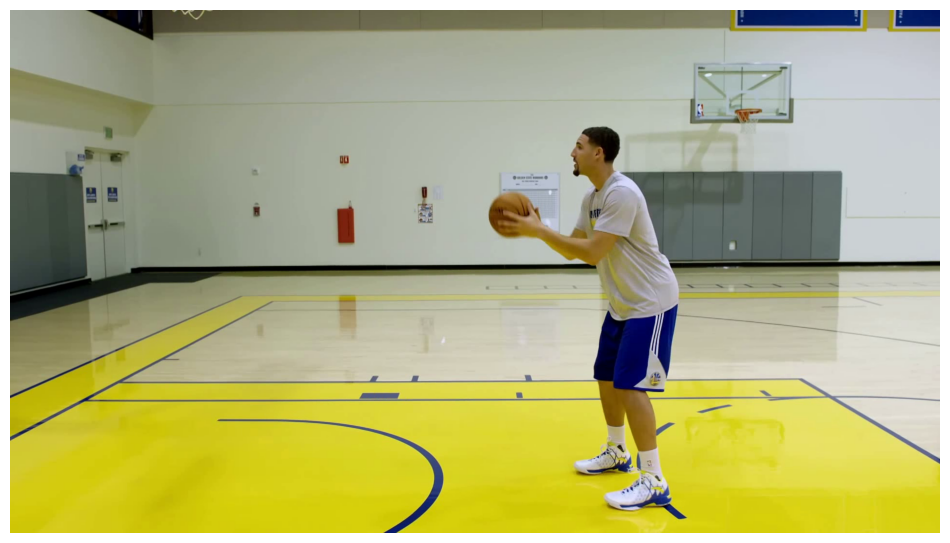

In [5]:
# (Opcional) Visualizar um frame específico do vídeo anotado com a bola
cap_teste = cv2.VideoCapture(saida_video_bola)

tempo_desejado = 2.049133333333333  # altere aqui o segundo que você quer ver
frame_desejado = int(tempo_desejado * fps)

cap_teste.set(cv2.CAP_PROP_POS_FRAMES, frame_desejado)
ret, frame = cap_teste.read()
cap_teste.release()

if ret:
    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(12, 8))
    plt.imshow(frame_rgb)
    plt.axis("off")
    plt.show()
else:
    print("Não foi possível carregar esse frame.")

In [6]:
#DETECTAR POSE COM MEDIAPIPE + FUSÃO COM DADOS DA BOLA

PoseLandmarker        = mp.tasks.vision.PoseLandmarker
PoseLandmarkerOptions  = mp.tasks.vision.PoseLandmarkerOptions

LANDMARK_NAMES = [
    "nose", "left_eye_inner", "left_eye", "left_eye_outer",
    "right_eye_inner", "right_eye", "right_eye_outer",
    "left_ear", "right_ear", "mouth_left", "mouth_right",
    "left_shoulder", "right_shoulder", "left_elbow", "right_elbow",
    "left_wrist", "right_wrist", "left_pinky", "right_pinky",
    "left_index", "right_index", "left_thumb", "right_thumb",
    "left_hip", "right_hip", "left_knee", "right_knee",
    "left_ankle", "right_ankle", "left_heel", "right_heel",
    "left_foot_index", "right_foot_index",
]

df_bola = pd.read_csv(saida_csv_bola)

cap = cv2.VideoCapture(video_path)
fps     = cap.get(cv2.CAP_PROP_FPS)
largura = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
altura  = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

out = cv2.VideoWriter(saida_video_final, cv2.VideoWriter_fourcc(*"mp4v"), fps, (largura, altura))

pose_options = PoseLandmarkerOptions(
    base_options=mp.tasks.BaseOptions(model_asset_path=pose_model_path),
    running_mode=mp.tasks.vision.RunningMode.VIDEO,
    num_poses=5,
    min_pose_detection_confidence=0.5,
    min_pose_presence_confidence=0.5,
    min_tracking_confidence=0.5,
    output_segmentation_masks=False,
)

dados_completos = []

with PoseLandmarker.create_from_options(pose_options) as pose_detector:
    frame_num = 0

    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break

        timestamp_ms = int((frame_num / fps) * 1000)
        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        mp_image  = mp.Image(image_format=mp.ImageFormat.SRGB, data=frame_rgb)

        resultado_pose = pose_detector.detect_for_video(mp_image, timestamp_ms)

        row_bola = df_bola[df_bola["frame"] == frame_num].iloc[0] if frame_num < len(df_bola) else None

        registro_base = {
            "frame": frame_num,
            "tempo_segundos": frame_num / fps,
            "bola_detectada": row_bola["bola_detectada"] if row_bola is not None else False,
            "bola_x":         row_bola["bola_x"]         if row_bola is not None else None,
            "bola_y":         row_bola["bola_y"]         if row_bola is not None else None,
            "bola_confianca": row_bola["confianca"]       if row_bola is not None else None,
        }

        if resultado_pose.pose_landmarks:
            for pessoa_id, landmarks in enumerate(resultado_pose.pose_landmarks):
                registro = registro_base.copy()
                registro["pessoa_id"]      = pessoa_id
                registro["pose_detectada"] = True

                for idx, lm in enumerate(landmarks):
                    nome = LANDMARK_NAMES[idx]
                    registro[f"{nome}_x"]   = round(lm.x * largura, 2)
                    registro[f"{nome}_y"]   = round(lm.y * altura,  2)
                    registro[f"{nome}_z"]   = round(lm.z, 4)
                    registro[f"{nome}_vis"] = round(lm.visibility, 3)

                dados_completos.append(registro)

                CONEXOES = [
                    ("left_shoulder", "right_shoulder"),
                    ("left_shoulder", "left_elbow"), ("left_elbow", "left_wrist"),
                    ("right_shoulder", "right_elbow"), ("right_elbow", "right_wrist"),
                    ("left_shoulder", "left_hip"), ("right_shoulder", "right_hip"),
                    ("left_hip", "right_hip"),
                    ("left_hip", "left_knee"), ("left_knee", "left_ankle"),
                    ("right_hip", "right_knee"), ("right_knee", "right_ankle"),
                ]

                pts = {
                    LANDMARK_NAMES[i]: (int(lm.x * largura), int(lm.y * altura))
                    for i, lm in enumerate(landmarks)
                }

                COR_ESQUELETO = (0, 255, 0)
                for (a, b) in CONEXOES:
                    if a in pts and b in pts:
                        cv2.line(frame, pts[a], pts[b], COR_ESQUELETO, 2)

                for nome_pt, coord in pts.items():
                    cv2.circle(frame, coord, 4, (255, 255, 0), -1)
        else:
            registro = registro_base.copy()
            registro["pessoa_id"]      = None
            registro["pose_detectada"] = False
            dados_completos.append(registro)

        if row_bola is not None and row_bola["bola_detectada"]:
            x1 = int(row_bola["bbox_x"])
            y1 = int(row_bola["bbox_y"])
            w  = int(row_bola["bbox_largura"])
            h  = int(row_bola["bbox_altura"])
            cx = int(row_bola["bola_x"])
            cy = int(row_bola["bola_y"])
            cv2.rectangle(frame, (x1, y1), (x1 + w, y1 + h), (0, 255, 255), 3)
            cv2.circle(frame, (cx, cy), 5, (0, 0, 255), -1)
            cv2.putText(frame, f"Bola {row_bola['confianca']:.2f}", (x1, y1 - 10),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 255), 2)

        out.write(frame)
        frame_num += 1

        if frame_num % 50 == 0:
            print(f"Pose: frame {frame_num}/{total_frames}")

cap.release()
out.release()

df_final = pd.DataFrame(dados_completos)
df_final.to_csv(saida_csv_final, index=False)

print("\nConcluído!")
print(f"Vídeo: {saida_video_final}")
print(f"CSV:   {saida_csv_final}")
print(f"Colunas: {len(df_final.columns)} | Linhas: {len(df_final)}")
df_final.head()

Pose: frame 50/152
Pose: frame 100/152
Pose: frame 150/152

Concluído!
Vídeo: video_bola_pose.mp4
CSV:   dados_bola_pose.csv
Colunas: 140 | Linhas: 153


,frame,tempo_segundos,bola_detectada,bola_x,bola_y,bola_confianca,pessoa_id,pose_detectada,nose_x,nose_y,...,right_heel_z,right_heel_vis,left_foot_index_x,left_foot_index_y,left_foot_index_z,left_foot_index_vis,right_foot_index_x,right_foot_index_y,right_foot_index_z,right_foot_index_vis
0,0,0.000000,True,1226.0,566.0,0.230469,0,True,1218.97,305.83,...,0.2473,0.889,1243.75,1022.57,-0.1499,0.981,1181.60,965.66,0.1796,0.946
1,1,0.033333,True,1189.0,558.0,0.230469,0,True,1219.05,304.48,...,0.2393,0.868,1237.26,1021.04,-0.1350,0.967,1183.12,966.39,0.1760,0.925
2,2,0.066667,False,NaN,NaN,NaN,0,True,1219.35,302.98,...,0.2683,0.887,1247.62,1008.55,-0.1153,0.981,1181.74,963.20,0.2093,0.948
3,3,0.100000,False,NaN,NaN,NaN,0,True,1219.64,302.68,...,0.2548,0.885,1257.19,998.25,-0.0734,0.976,1180.64,958.26,0.1968,0.931
4,4,0.133333,False,NaN,NaN,NaN,0,True,1218.56,297.19,...,0.2790,0.820,1243.14,1015.31,-0.1097,0.980,1177.09,957.78,0.2249,0.894


In [7]:
# FRAME DE SOLTURA — agrupa por frame antes de filtrar

df = pd.read_csv(saida_csv_final)

def dist_pulso(row):
    if pd.isna(row.get("bola_x")):
        return np.nan
    resultados = []
    for lado in ["right_wrist", "left_wrist"]:
        x_col, y_col = f"{lado}_x", f"{lado}_y"
        if not pd.isna(row.get(x_col, np.nan)):
            d = np.sqrt((row["bola_x"] - row[x_col]) ** 2 + (row["bola_y"] - row[y_col]) ** 2)
            resultados.append(d)
    return min(resultados) if resultados else np.nan

df["dist_pulso_min"] = df.apply(dist_pulso, axis=1)

df_frame = df.groupby("frame").agg(
    tempo_segundos = ("tempo_segundos", "first"),
    bola_detectada = ("bola_detectada", "first"),
    bola_x         = ("bola_x", "first"),
    bola_y         = ("bola_y", "first"),
    bola_confianca = ("bola_confianca", "first"),
    pose_detectada = ("pose_detectada", "any"),
    dist_pulso_min = ("dist_pulso_min", "min"),
).reset_index()

df_frame["dist_suavizada"] = (
    df_frame["dist_pulso_min"].rolling(window=5, center=True, min_periods=1).mean()
)

frames_iniciais = df_frame[df_frame["bola_detectada"] == True].head(60)
if len(frames_iniciais) > 0:
    LIMIAR_FORA_DA_MAO = np.percentile(frames_iniciais["dist_suavizada"].dropna(), 70)
    print(f"Limiar automático: {LIMIAR_FORA_DA_MAO:.1f}px")
else:
    LIMIAR_FORA_DA_MAO = 80
    print(f"Limiar padrão: {LIMIAR_FORA_DA_MAO}px")

mask = (
    (df_frame["bola_detectada"] == True)
    & (df_frame["pose_detectada"] == True)
    & (df_frame["dist_suavizada"] > LIMIAR_FORA_DA_MAO)
)

candidatos = df_frame[mask]

if len(candidatos) == 0:
    raise ValueError("Nenhum frame de soltura encontrado. Reduza LIMIAR_FORA_DA_MAO.")

frame_soltura = int(candidatos.iloc[0]["frame"])
row_resumo    = candidatos.iloc[0]
print(f"\nFrame de soltura: {frame_soltura}")
print(f"Tempo:            {row_resumo['tempo_segundos']:.3f}s")
print(f"Dist bola→pulso:  {row_resumo['dist_suavizada']:.1f}px")
print(f"Limiar usado:     {LIMIAR_FORA_DA_MAO:.1f}px")

Limiar automático: 255.3px

Frame de soltura: 5
Tempo:            0.167s
Dist bola→pulso:  393.3px
Limiar usado:     255.3px


In [8]:
# Exporta todas as linhas (uma por pessoa detectada) do frame de soltura
df_soltura = df[df["frame"] == frame_soltura].copy()
df_soltura["dist_pulso_min"] = df_soltura.apply(dist_pulso, axis=1)
df_soltura["dist_suavizada"] = row_resumo["dist_suavizada"]
df_soltura["limiar_usado"]   = LIMIAR_FORA_DA_MAO
df_soltura["evento"]         = "soltura_bola"

df_soltura.to_csv(saida_csv_soltura, index=False)
print(f"Salvo: {saida_csv_soltura}")
print(f"Pessoas detectadas no frame: {len(df_soltura)}")
df_soltura.T

Salvo: frame_soltura.csv
Pessoas detectadas no frame: 1


,5
frame,5
tempo_segundos,0.166667
bola_detectada,True
bola_x,1525.0
bola_y,233.0
...,...
right_foot_index_vis,0.913
dist_pulso_min,430.263366
dist_suavizada,393.30035
limiar_usado,255.340723


## 4) Cálculo das métricas do TCC

As duas métricas escolhidas para avaliar o arremesso são:
- **Ângulo interno de flexão do joelho** (ângulo entre quadril–joelho–tornozelo)
- **Ângulo do antebraço em relação a uma linha vertical imaginária** (a partir do cotovelo, usando cotovelo→pulso)

Calculamos os dois lados (esquerdo e direito) e escolhemos automaticamente o **lado de arremesso** como aquele cujo pulso está mais próximo da bola no frame de soltura.

In [9]:
def angulo_3_pontos(a, b, c):
    """Ângulo interno (em graus) no vértice b, formado pelos pontos a-b-c."""
    a, b, c = np.array(a, dtype=float), np.array(b, dtype=float), np.array(c, dtype=float)
    ba = a - b
    bc = c - b
    if np.linalg.norm(ba) == 0 or np.linalg.norm(bc) == 0:
        return np.nan
    cos_ang = np.dot(ba, bc) / (np.linalg.norm(ba) * np.linalg.norm(bc))
    cos_ang = np.clip(cos_ang, -1.0, 1.0)
    return math.degrees(math.acos(cos_ang))


def angulo_com_vertical(ponto_proximal, ponto_distal):
    """Ângulo (em graus) do segmento proximal->distal em relação a uma vertical imaginária
    que passa pelo ponto proximal. 0° = braço apontando reto para cima/baixo."""
    proximal = np.array(ponto_proximal, dtype=float)
    distal   = np.array(ponto_distal, dtype=float)
    vetor = distal - proximal
    if np.linalg.norm(vetor) == 0:
        return np.nan
    # Vertical: eixo y da imagem aponta para baixo, então "para cima" é (0, -1)
    vertical = np.array([0.0, -1.0])
    cos_ang = np.dot(vetor, vertical) / np.linalg.norm(vetor)
    cos_ang = np.clip(cos_ang, -1.0, 1.0)
    return math.degrees(math.acos(cos_ang))

In [10]:
# ==========================================================
# Calcula as métricas para cada pessoa detectada no frame de soltura
# ==========================================================

def get_ponto(row, nome):
    x, y = row.get(f"{nome}_x"), row.get(f"{nome}_y")
    if pd.isna(x) or pd.isna(y):
        return None
    return (x, y)

resultados_metricas = []

for _, row in df_soltura.iterrows():
    if not row.get("pose_detectada", False):
        continue

    metricas = {"frame": row["frame"], "pessoa_id": row.get("pessoa_id")}

    for lado in ["left", "right"]:
        quadril    = get_ponto(row, f"{lado}_hip")
        joelho     = get_ponto(row, f"{lado}_knee")
        tornozelo  = get_ponto(row, f"{lado}_ankle")
        cotovelo   = get_ponto(row, f"{lado}_elbow")
        pulso      = get_ponto(row, f"{lado}_wrist")

        ang_joelho = angulo_3_pontos(quadril, joelho, tornozelo) if quadril and joelho and tornozelo else np.nan
        ang_antebraco = angulo_com_vertical(cotovelo, pulso) if cotovelo and pulso else np.nan

        metricas[f"angulo_joelho_{lado}"] = ang_joelho
        metricas[f"angulo_antebraco_{lado}"] = ang_antebraco

        # distância pulso-bola desse lado, para decidir o lado de arremesso
        if pulso is not None and not pd.isna(row.get("bola_x")):
            metricas[f"dist_bola_pulso_{lado}"] = math.dist(pulso, (row["bola_x"], row["bola_y"]))
        else:
            metricas[f"dist_bola_pulso_{lado}"] = np.nan

    # Lado de arremesso = pulso mais próximo da bola
    dist_l = metricas.get("dist_bola_pulso_left", np.nan)
    dist_r = metricas.get("dist_bola_pulso_right", np.nan)

    if pd.isna(dist_l) and pd.isna(dist_r):
        lado_arremesso = None
    elif pd.isna(dist_r) or (not pd.isna(dist_l) and dist_l <= dist_r):
        lado_arremesso = "left"
    else:
        lado_arremesso = "right"

    metricas["lado_arremesso"] = lado_arremesso
    if lado_arremesso is not None:
        metricas["angulo_joelho_arremesso"]    = metricas[f"angulo_joelho_{lado_arremesso}"]
        metricas["angulo_antebraco_arremesso"] = metricas[f"angulo_antebraco_{lado_arremesso}"]
    else:
        metricas["angulo_joelho_arremesso"]    = np.nan
        metricas["angulo_antebraco_arremesso"] = np.nan

    resultados_metricas.append(metricas)

df_metricas = pd.DataFrame(resultados_metricas)
df_metricas.to_csv(saida_csv_metricas, index=False)

print(f"Salvo: {saida_csv_metricas}")
df_metricas

Salvo: metricas_arremesso.csv


,frame,pessoa_id,angulo_joelho_left,angulo_antebraco_left,dist_bola_pulso_left,angulo_joelho_right,angulo_antebraco_right,dist_bola_pulso_right,lado_arremesso,angulo_joelho_arremesso,angulo_antebraco_arremesso
0,5,0,171.450295,130.429602,476.143249,178.147901,15.631623,430.263366,right,178.147901,15.631623


In [11]:
# Resumo legível das métricas do arremesso
for _, m in df_metricas.iterrows():
    print(f"Pessoa {m['pessoa_id']} — lado de arremesso: {m['lado_arremesso']}")
    print(f"  Ângulo do joelho:     {m['angulo_joelho_arremesso']:.1f}°")
    print(f"  Ângulo do antebraço:  {m['angulo_antebraco_arremesso']:.1f}° em relação à vertical")
    print()

Pessoa 0 — lado de arremesso: right
  Ângulo do joelho:     178.1°
  Ângulo do antebraço:  15.6° em relação à vertical

